In [1]:
# want the cosine similarity between SBS288B and SBS288D and their 96 and 1536 versions 
# everything will need to be collapsed into the SBS96 version 


import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
# Supplementary Figure 1a-b are direct plots from the extractions
# performed as part of the original Mutographs CRC paper

In [4]:
SBS288_denovos = pd.read_table('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V3_data/Sigs_288.txt',index_col=0)


SBS288_denovos.index = SBS288_denovos.index.str.split(':').str[-1]
SBS288_denovos = SBS288_denovos.groupby(SBS288_denovos.index).sum()



SBS96_denovos = pd.read_table('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/MSA_testing_SBS96B/mutographs_SBS96_extraction/Suggested_Solution/SBS96_De-Novo_Solution/SPA_cosmic_fit/Signatures/Assignment_Solution_Signatures.txt',
                             index_col=0)


# need to figure out which ones in the 96 context are SBS288B and SBS288D

# SBS96B = SBS288B
# SBS96C = SBS288D

SBS1536_denovos = pd.read_table('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/MSA_testing_SBS96B/mutographs_SBS1536_extraction/Suggested_Solution/S14_Solution/De_Novo_Solution/SPA_cosmic_fit/Signatures/Assignment_Solution_Signatures.txt',
                             index_col=0)


SBS1536_denovos.index = SBS1536_denovos.index.str[1:8]
SBS1536_denovos = SBS1536_denovos.groupby(SBS1536_denovos.index).sum()

# SBS1536B = SBS288B
# SBS1536D = SBS288D

SBS288B = SBS288_denovos.loc[:,'SBS288B']
SBS288B.name = 'SBS_B_288'

SBS288D = SBS288_denovos.loc[:,'SBS288D']
SBS288D.name = 'SBS_D_288'

SBS96B = SBS96_denovos.loc[:,'SBS96B']
SBS96B.name = 'SBS_B_96'

SBS96C = SBS96_denovos.loc[:,'SBS96C']
SBS96C.name = 'SBS_D_96'

SBS1536B = SBS1536_denovos.loc[:,'SBS1536B']
SBS1536B.name = 'SBS_B_1536'

SBS1536D = SBS1536_denovos.loc[:,'SBS1536D']
SBS1536D.name = 'SBS_D_1536'

all_B_D = pd.concat([SBS96B,SBS288B,SBS1536B,SBS96C,SBS288D,SBS1536D],axis=1)

from sklearn.metrics.pairwise import cosine_similarity


cs = pd.DataFrame(cosine_similarity(all_B_D.T),
            index = all_B_D.columns,
            columns = all_B_D.columns)

cs_ = cs.copy()

cs_.index = cs_.index.str.replace('_B','18^\n')
cs_.columns = cs_.columns.str.replace('_B','18^\n')


cs_.index = cs_.index.str.replace('_D_','_D\n')
cs_.columns = cs_.columns.str.replace('_D_','_D\n')


cs_.index = cs_.index.str.replace('_',' ')
cs_.columns = cs_.columns.str.replace('_',' ')


cs_.index = cs_.index.str.replace(' D','_D')
cs_.columns = cs_.columns.str.replace(' D','_D')

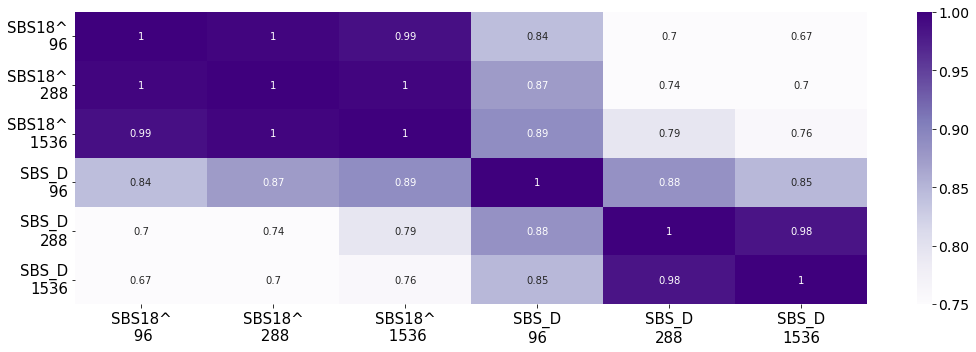

In [5]:
######### Supplementary Figure 1c #########


fig,ax = plt.subplots(figsize=(15,5))
sns.heatmap(cs_,cmap='Purples',annot=True,vmin=.75)

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
                     ax.get_xticklabels() + ax.get_yticklabels()):
            item.set_fontsize(15)
# plt.xticks(rotation=30)
plt.yticks(rotation=0)
cbar = ax.collections[0].colorbar
# here set the labelsize by 20
cbar.ax.tick_params(labelsize=14)
plt.tight_layout()
# plt.savefig('plots_for_paper/CS_different_contexts.png',dpi=300)